In [ ]:
from google.colab import drive
import pandas as pd

# Importaciones necesarias
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


In [ ]:
#Google Drive
drive.mount('/content/drive')

# Ruta
file_path = "/content/drive/MyDrive/Colab Notebooks/IDA_LIMPIO.csv"

# Leer el archivo CSV
df = pd.read_csv(file_path)

Mounted at /content/drive


In [ ]:
date_columns = [
    'End of Period', 'First Repayment Date', 'Last Repayment Date',
    'Agreement Signing Date', 'Board Approval Date', 'Effective Date (Most Recent)',
    'Closed Date (Most Recent)']
df[date_columns] = df[date_columns].apply(pd.to_datetime, errors='coerce')

df['Region'] = df['Region'].str.upper()
df['Credit Number'] = df['Credit Number'].astype('string')
df['credit_status_group'] = df['credit_status_group'].astype('string')

In [ ]:
date_cols = ['First Repayment Date', 'Last Repayment Date']
df = df.assign(**{
    **{f'{col}_year': df[col].dt.year for col in date_cols},
    **{f'{col}_month': df[col].dt.month for col in date_cols},
    **{f'{col}_day': df[col].dt.day for col in date_cols},
})

## Modelo 1

In [ ]:
# 1. Definir features
numeric_features = ['Original Principal Amount (US$)', 'Service Charge Rate','Cancelled Amount (US$)', 'Undisbursed Amount (US$)','Disbursed Amount (US$)', 'Repaid to IDA (US$)',
                    'Due to IDA (US$)','Borrower\'s Obligation (US$)','First Repayment Date_year' ,'Last Repayment Date_year' ,'First Repayment Date_month' ,'Last Repayment Date_month',
                    'First Repayment Date_day','Last Repayment Date_day']
categorical_features = ['Region', 'borrower_type','Country / Economy Code']

# 2. Preprocesamiento diferenciado
preprocessor = ColumnTransformer([
    ('num', RobustScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)  # One-Hot para categóricas
])

# 3. Pipeline
kmeans_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('cluster', KMeans(
        n_clusters=4,
        random_state=42,
        n_init=10  # Número de inicializaciones
    ))
])

# 4. Entrenamiento
kmeans_pipe.fit(df)

# 5. Asignar clusters
df['cluster'] = kmeans_pipe.predict(df)

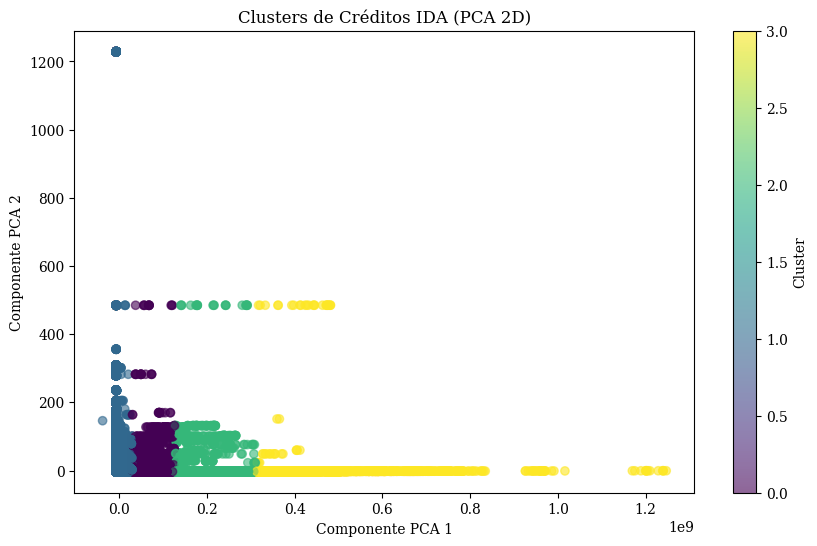

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Obtener datos preprocesados
X_preprocessed = kmeans_pipe.named_steps['preprocessor'].transform(df)

# Reducir a 2D con PCA
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_preprocessed)

# Graficar
plt.rcParams['font.family'] = 'serif'
plt.figure(figsize=(10, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=df['cluster'], cmap='viridis', alpha=0.6)
plt.title('Clusters de Créditos IDA (PCA 2D)')
plt.colorbar(label='Cluster')
plt.xlabel('Componente PCA 1')
plt.ylabel('Componente PCA 2')
plt.show()

In [ ]:
pd.set_option('display.float_format', '{:.3f}'.format)
cluster_means = df.groupby('cluster').mean(numeric_only=True)
print(cluster_means)

         Service Charge Rate  Original Principal Amount (US$)  \
cluster                                                         
0                      1.230                    118796389.496   
1                      0.844                     40398040.787   
2                      1.325                    248772423.928   
3                      1.301                    508784191.106   

         Cancelled Amount (US$)  Undisbursed Amount (US$)  \
cluster                                                     
0                   2420348.593              72521680.844   
1                   3287816.390               1025534.110   
2                   2909559.444             195443395.086   
3                   4420630.447             441382653.392   

         Disbursed Amount (US$)  Repaid to IDA (US$)  Due to IDA (US$)  \
cluster                                                                  
0                  40528327.903           763283.569      39082686.954   
1                  3

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1147036 entries, 0 to 1147035
Data columns (total 40 columns):
 #   Column                           Non-Null Count    Dtype         
---  ------                           --------------    -----         
 0   End of Period                    1147036 non-null  datetime64[ns]
 1   Credit Number                    1147036 non-null  string        
 2   Region                           1147036 non-null  object        
 3   Country / Economy Code           1147036 non-null  object        
 4   Country / Economy                1147036 non-null  object        
 5   Borrower                         1146669 non-null  object        
 6   Credit Status                    1147036 non-null  object        
 7   Service Charge Rate              1147036 non-null  float64       
 8   Currency of Commitment           1147036 non-null  object        
 9   Project ID                       1147036 non-null  object        
 10  Project Name                  

In [ ]:
# Configurar pandas para mostrar 3 decimales y desactivar notación científica
pd.set_option('display.float_format', '{:,.3f}'.format)
pd.set_option('display.max_columns', None)

# Definir las columnas de componentes de fecha que nos interesan
date_components_es = {
    'First Repayment Date_year': 'Año Primer Reembolso',
    'Last Repayment Date_year': 'Año Último Reembolso',
    'First Repayment Date_month': 'Mes Primer Reembolso',
    'Last Repayment Date_month': 'Mes Último Reembolso',
    'First Repayment Date_day': 'Día Primer Reembolso',
    'Last Repayment Date_day': 'Día Último Reembolso'
}

# Filtrar solo las columnas que existen en el DataFrame
existing_features = [col for col in date_components_es.keys() if col in df.columns]

# Calcular medias por cluster solo para estas columnas
cluster_means = df.groupby('cluster')[existing_features].mean(numeric_only=True)

# Redondear los valores (especialmente importante para mes y día)
cluster_means = cluster_means.round({
    'First Repayment Date_year': 0,
    'Last Repayment Date_year': 0,
    'First Repayment Date_month': 1,
    'Last Repayment Date_month': 1,
    'First Repayment Date_day': 1,
    'Last Repayment Date_day': 1
})

# Renombrar las columnas al español
cluster_means = cluster_means.rename(columns=date_components_es)

# Mostrar tabla con estilo profesional
(cluster_means
 .style
 .set_properties(**{'text-align': 'center'})
 .set_table_styles([{
     'selector': 'th',
     'props': [('text-align', 'center')]
 }])
 .format({
     'Año Primer Reembolso': '{:,.0f}',
     'Año Último Reembolso': '{:,.0f}',
     'Mes Primer Reembolso': '{:,.1f}',
     'Mes Último Reembolso': '{:,.1f}',
     'Día Primer Reembolso': '{:,.1f}',
     'Día Último Reembolso': '{:,.1f}'
 })
 .set_caption("<b>Promedio de Componentes de Fechas por Cluster</b>")
 .background_gradient(cmap='Blues', subset=cluster_means.columns[:2])  # Resaltar solo años
)

,Año Primer Reembolso,Año Último Reembolso,Mes Primer Reembolso,Mes Último Reembolso,Día Primer Reembolso,Día Último Reembolso
cluster,,,,,,
0,"2,022","2,049",7.6,5.8,11.2,11.3
1,"2,005","2,036",7.3,5.9,9.2,9.2
2,"2,023","2,049",7.7,5.7,10.4,10.4
3,"2,023","2,050",7.2,5.3,8.9,8.9


In [ ]:
# Configurar pandas para mostrar 3 decimales y desactivar notación científica
pd.set_option('display.float_format', '{:,.3f}'.format)
pd.set_option('display.max_columns', None)

# Definir las columnas numéricas de interés (usando los nombres en español que tienes en tu DataFrame)
numeric_features_es = {
    'Monto Principal Original (US$)': 'Monto Principal Original (US$)',
    'Tasa de Comisión de Servicio': 'Tasa de Comisión de Servicio',
    'Monto Cancelado (US$)': 'Monto Cancelado (US$)',
    'Monto No Desembolsado (US$)': 'Monto No Desembolsado (US$)',
    'Monto Desembolsado (US$)': 'Monto Desembolsado (US$)',
    'Reembolsado a AIF (US$)': 'Reembolsado a AIF (US$)',
    'Deuda con AIF (US$)': 'Deuda con AIF (US$)'
}

# Filtrar solo las columnas que existen en el DataFrame
existing_features = [col for col in numeric_features_es.keys() if col in df.columns]

# Calcular medias por cluster solo para estas columnas
cluster_means = df.groupby('cluster')[existing_features].mean(numeric_only=True)

# Mostrar tabla con estilo profesional
(cluster_means
 .style
 .set_properties(**{'text-align': 'center'})
 .set_table_styles([{
     'selector': 'th',
     'props': [('text-align', 'center')]
 }])
 .format("{:,.3f}")
 .set_caption("<b>Análisis Promedio por Cluster</b>")
 .background_gradient(cmap='Blues', subset=cluster_means.columns[:7])  # Resaltar primeras 5 columnas
)

cluster
0
1
2
3


In [ ]:
# Configurar pandas para mostrar 3 decimales y desactivar notación científica
pd.set_option('display.float_format', '{:,.3f}'.format)
pd.set_option('display.max_columns', None)

# Definir las columnas numéricas de interés con sus nombres en español
numeric_features_es = {
    'Original Principal Amount (US$)': 'Monto Principal Original (US$)',
    'Service Charge Rate': 'Tasa de Comisión de Servicio',
    'Cancelled Amount (US$)': 'Monto Cancelado (US$)',
    'Undisbursed Amount (US$)': 'Monto No Desembolsado (US$)',
    'Disbursed Amount (US$)': 'Monto Desembolsado (US$)',
    'Repaid to IDA (US$)': 'Reembolsado a AIF (US$)',
    'Due to IDA (US$)': 'Deuda con AIF (US$)'
}

# Filtrar solo las columnas que existen en el DataFrame
existing_features = [col for col in numeric_features_es.keys() if col in df.columns]

# Calcular medias por cluster solo para estas columnas
cluster_means = df.groupby('cluster')[existing_features].mean(numeric_only=True)

# Renombrar las columnas al español
cluster_means = cluster_means.rename(columns=numeric_features_es)

# Mostrar tabla con estilo profesional
(cluster_means
 .style
 .set_properties(**{'text-align': 'center'})
 .set_table_styles([{
     'selector': 'th',
     'props': [('text-align', 'center')]
 }])
 .format("{:,.3f}")
 .set_caption("<b>Análisis Promedio por Cluster</b>")
 .background_gradient(cmap='Blues', subset=cluster_means.columns[:5])  # Resaltar primeras 5 columnas
)

,Monto Principal Original (US$),Tasa de Comisión de Servicio,Monto Cancelado (US$),Monto No Desembolsado (US$),Monto Desembolsado (US$),Reembolsado a AIF (US$),Deuda con AIF (US$)
cluster,,,,,,,
0,"118,796,389.496",1.230,"2,420,348.593","72,521,680.844","40,528,327.903","763,283.569","39,082,686.954"
1,"40,398,040.787",0.844,"3,287,816.390","1,025,534.110","36,539,243.390","15,494,786.936","21,467,296.822"
2,"248,772,423.928",1.325,"2,909,559.444","195,443,395.086","44,723,876.269","249,443.648","43,951,481.742"
3,"508,784,191.106",1.301,"4,420,630.447","441,382,653.392","52,230,514.297","40,173.598","51,861,165.650"


In [ ]:
df.groupby('cluster')['Region'].value_counts(normalize=True)


cluster  Region                      
0        AFRICA                         0.317
         SOUTH ASIA                     0.239
         EAST ASIA AND PACIFIC          0.127
         WESTERN AND CENTRAL AFRICA     0.091
         EASTERN AND SOUTHERN AFRICA    0.068
         EUROPE AND CENTRAL ASIA        0.044
         AFRICA WEST                    0.043
         AFRICA EAST                    0.041
         LATIN AMERICA AND CARIBBEAN    0.024
         MIDDLE EAST AND NORTH AFRICA   0.008
1        AFRICA                         0.318
         SOUTH ASIA                     0.184
         EAST ASIA AND PACIFIC          0.096
         EUROPE AND CENTRAL ASIA        0.086
         LATIN AMERICA AND CARIBBEAN    0.077
         WESTERN AND CENTRAL AFRICA     0.065
         EASTERN AND SOUTHERN AFRICA    0.062
         MIDDLE EAST AND NORTH AFRICA   0.041
         AFRICA WEST                    0.035
         AFRICA EAST                    0.034
2        SOUTH ASIA                     0.343
         AFRICA                         0.264
         EAST ASIA AND PACIFIC          0.115
         EASTERN AND SOUTHERN AFRICA    0.085
         WESTERN AND CENTRAL AFRICA     0.079
         AFRICA EAST                    0.046
         AFRICA WEST                    0.040
         EUROPE AND CENTRAL ASIA        0.026
         LATIN AMERICA AND CARIBBEAN    0.001
3        SOUTH ASIA                     0.410
         AFRICA                         0.216
         EASTERN AND SOUTHERN AFRICA    0.110
         WESTERN AND CENTRAL AFRICA     0.095
         EAST ASIA AND PACIFIC          0.066
         AFRICA EAST                    0.047
         AFRICA WEST                    0.044
         EUROPE AND CENTRAL ASIA        0.012
Name: proportion, dtype: float64

In [ ]:
# Ver distribución de estados por cluster
pd.crosstab(df['cluster'], df['credit_status_group'], normalize='index') * 100

credit_status_group,Activo,Cancelado,No Desembolsado,Reembolsado
cluster,,,,
0,93.723,0.000,6.277,0.000
1,65.503,1.168,0.313,33.016
2,92.017,0.000,7.983,0.000
3,90.270,0.000,9.730,0.000


In [14]:
import pandas as pd
from tabulate import tabulate

# Datos de ejemplo (simulando tu DataFrame)
data = {
    'cluster': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3],
    'Region': ['AFRICA', 'SOUTH ASIA', 'EAST ASIA AND PACIFIC', 'WESTERN AND CENTRAL AFRICA', 'EASTERN AND SOUTHERN AFRICA', 'EUROPE AND CENTRAL ASIA', 'AFRICA WEST', 'AFRICA EAST', 'LATIN AMERICA AND CARIBBEAN', 'MIDDLE EAST AND NORTH AFRICA', 'AFRICA', 'SOUTH ASIA', 'EAST ASIA AND PACIFIC', 'EUROPE AND CENTRAL ASIA', 'LATIN AMERICA AND CARIBBEAN', 'WESTERN AND CENTRAL AFRICA', 'EASTERN AND SOUTHERN AFRICA', 'MIDDLE EAST AND NORTH AFRICA', 'AFRICA WEST', 'AFRICA EAST', 'SOUTH ASIA', 'AFRICA', 'EAST ASIA AND PACIFIC', 'EASTERN AND SOUTHERN AFRICA', 'WESTERN AND CENTRAL AFRICA', 'AFRICA EAST', 'AFRICA WEST', 'EUROPE AND CENTRAL ASIA', 'LATIN AMERICA AND CARIBBEAN', 'SOUTH ASIA', 'AFRICA', 'EASTERN AND SOUTHERN AFRICA', 'WESTERN AND CENTRAL AFRICA', 'EAST ASIA AND PACIFIC', 'AFRICA EAST', 'AFRICA WEST', 'EUROPE AND CENTRAL ASIA'],
    'proportion': [0.317, 0.239, 0.127, 0.091, 0.068, 0.044, 0.043, 0.041, 0.024, 0.008, 0.318, 0.184, 0.096, 0.086, 0.077, 0.065, 0.062, 0.041, 0.035, 0.034, 0.343, 0.264, 0.115, 0.085, 0.079, 0.046, 0.040, 0.026, 0.001, 0.410, 0.216, 0.110, 0.095, 0.066, 0.047, 0.044, 0.012]
}

df = pd.DataFrame(data)

# Traducción de regiones al español
region_translation = {
    'AFRICA': 'África',
    'SOUTH ASIA': 'Asia del Sur',
    'EAST ASIA AND PACIFIC': 'Este de Asia y Pacífico',
    'WESTERN AND CENTRAL AFRICA': 'África Occidental y Central',
    'EASTERN AND SOUTHERN AFRICA': 'África Oriental y Meridional',
    'EUROPE AND CENTRAL ASIA': 'Europa y Asia Central',
    'AFRICA WEST': 'África Occidental',
    'AFRICA EAST': 'África Oriental',
    'LATIN AMERICA AND CARIBBEAN': 'Latinoamérica y Caribe',
    'MIDDLE EAST AND NORTH AFRICA': 'Medio Oriente y Norte de África'
}

df['Region_ES'] = df['Region'].map(region_translation)

# Formatear proporción como porcentaje con 1 decimal
df['Proporción (%)'] = (df['proportion'] * 100).round(1).astype(str) + '%'

# Crear tabla resumen agrupada por cluster y región
summary_table = df[['cluster', 'Region_ES', 'Proporción (%)']]

# Mostrar tabla con formato estético usando tabulate
print(tabulate(summary_table,
               headers=['Cluster', 'Región', 'Proporción (%)'],
               tablefmt='grid',  # Puedes usar 'pretty', 'fancy_grid', etc.
               showindex=False,
               stralign='center'))

+-----------+---------------------------------+------------------+
|   Cluster |             Región              |  Proporción (%)  |
+===========+=================================+==================+
|         0 |             África              |      31.7%       |
+-----------+---------------------------------+------------------+
|         0 |          Asia del Sur           |      23.9%       |
+-----------+---------------------------------+------------------+
|         0 |     Este de Asia y Pacífico     |      12.7%       |
+-----------+---------------------------------+------------------+
|         0 |   África Occidental y Central   |       9.1%       |
+-----------+---------------------------------+------------------+
|         0 |  África Oriental y Meridional   |       6.8%       |
+-----------+---------------------------------+------------------+
|         0 |      Europa y Asia Central      |       4.4%       |
+-----------+---------------------------------+---------------